In [1]:
# step1_redthreads.ipynb
import numpy as np, pandas as pd

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from core.viz import plot_competency_effects, plot_competency_delta_bar
from core import io as IO
from core.io import (
    fetch_competency_wide_latest, fetch_strengths,
    fetch_for_competency_eda, fetch_for_psych_eda, 
    fetch_for_strengths_eda, fetch_for_contextual_eda,
    fetch_profiles_psych_full, fetch_perf_latest,
    fetch_papi_wide, fetch_profiles_psych_full
    )
from core.eda_competency import build_abt_competency, summarize_competency
from core.eda_psych import (
    summarize_papi, summarize_cognitive, 
    fix_disc_combination, summarize_disc,
    summarize_mbti_dimensions, summarize_mbti_types
    )
from core.eda_strengths import summarize_strengths
from core.eda_contextual import summarize_contextual
from core.evaluate import evaluate_all
from core.success_formula import compute_success_score_from_fetchers
from core.success_formula_v2 import success_score_v2

import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, auc, precision_recall_curve

# Competency Pillars

Kompetensi (skill-based pattern) apa yang paling membedakan karyawan dengan performa tinggi (rating 5) dari yang lain?

In [2]:
d = fetch_for_competency_eda()
abt = build_abt_competency(d)
comp_tbl = summarize_competency(abt, d["dim_comp_labels"])

In [3]:
comp_tbl.head(20)

,pillar_code,pillar_label,mean_high,mean_non,delta,cohens_d,p_mwu,n_high,n_non
0,SEA,Social Empathy & Awareness,5.234177,2.927775,2.306403,0.946072,1.250072e-63,158,1703
1,CEX,Curiosity & Experimentation,4.539474,2.965962,1.573511,0.631032,3.538349e-55,152,1704
2,VCU,Value Creation for Users,5.197452,3.175563,2.021889,0.396571,1.849590e-59,157,1686
3,STO,Synergy & Team Orientation,5.106250,3.149761,1.956489,0.383014,7.253751e-58,160,1676
4,CSI,Commercial Savvy & Impact,5.241830,3.219715,2.022115,0.362712,1.874813e-60,153,1684
5,QDD,Quality Delivery Discipline,4.691824,3.162114,1.529710,0.332387,3.677093e-67,159,1684
6,GDR,Growth Drive & Resilience,4.550336,3.132749,1.417587,0.309388,1.062192e-56,149,1710
7,LIE,"Lead, Inspire & Empower",4.581699,3.181926,1.399774,0.304665,2.840418e-58,153,1693
8,IDS,Insight & Decision Sharpness,4.535484,3.140000,1.395484,0.304058,2.062898e-57,155,1700
9,FTC,Forward Thinking & Clarity,4.548387,3.169601,1.378786,0.300755,5.030228e-56,155,1704


Tabel ini menampilkan hasil perbandingan **rata-rata skor 10 pilar kompetensi**
antara dua kelompok karyawan:

- **High performers** -> karyawan dengan `rating = 5`
- **Non-high performers** -> karyawan dengan `rating ≠ 5`

Tujuannya adalah untuk menemukan **pilar kompetensi yang paling membedakan**
antara kedua kelompok tersebut.

| Kolom | Makna | Cara Baca |
|:------|:------|:----------|
| `pillar_code` | Kode singkat pilar kompetensi (mis. SEA, CEX, dll.) | Identitas tiap pilar |
| `pillar_label` | Nama lengkap pilar | Berguna untuk storytelling dan visualisasi |
| `mean_high` / `mean_non` | Nilai rata-rata skor pilar per grup | Rata-rata kompetensi untuk high vs non-high |
| `delta` | Selisih (`mean_high - mean_non`) | Semakin besar -> pilar makin membedakan |
| `cohens_d` | *Effect size* (kekuatan perbedaan) | ≥0.8 besar, ≈0.5 sedang, <0.3 kecil |
| `p_mwu` | Nilai *p-value* uji Mann–Whitney U | <0.05 artinya perbedaan signifikan |
| `n_high` / `n_non` | Jumlah responden per grup | Validasi ukuran sampel |

---

## Interpretasi

Hasil analisis menunjukkan bahwa:

- **SEA (Social Empathy & Awareness)** memiliki *effect size* tertinggi (`d ≈ 0.95`),  
  artinya empati sosial dan kesadaran terhadap orang lain sangat kuat membedakan high performer.
- **CEX (Curiosity & Experimentation)** juga tinggi (`d ≈ 0.63`),  
  menunjukkan bahwa rasa ingin tahu dan kemauan untuk bereksperimen menjadi ciri khas performer unggul.
- Pilar seperti **VCU, STO, dan CSI** (`d ≈ 0.36–0.40`) memberi kontribusi sedang namun tetap signifikan.
- Pilar lain seperti **GDR, LIE, IDS, FTC** (`d ≈ 0.30`) tetap positif, namun pengaruhnya relatif kecil.

Semua nilai *p-value* berada di bawah 0.05, artinya perbedaan ini signifikan secara statistik.

---

### Kesimpulan Sementara

High performers secara konsisten menunjukkan keunggulan pada pilar:

> **SEA -> CEX -> VCU/STO/CSI**

Kombinasi ini menggambarkan pola **empati sosial**, **rasa ingin tahu**, dan **orientasi nilai pelanggan**  
sebagai *red thread* utama dari keberhasilan karyawan.

Nilai `cohens_d` dan `delta` dari tabel ini akan menjadi dasar awal dalam penentuan **bobot TV**  
untuk TGV **Competency** di *Success Formula* tahap berikutnya.

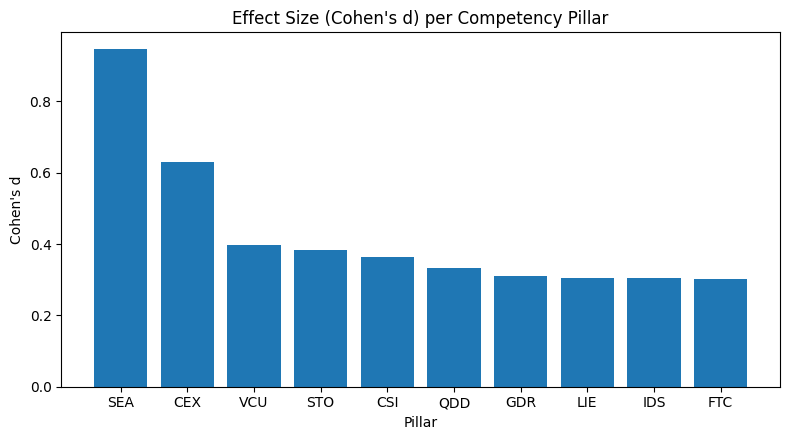

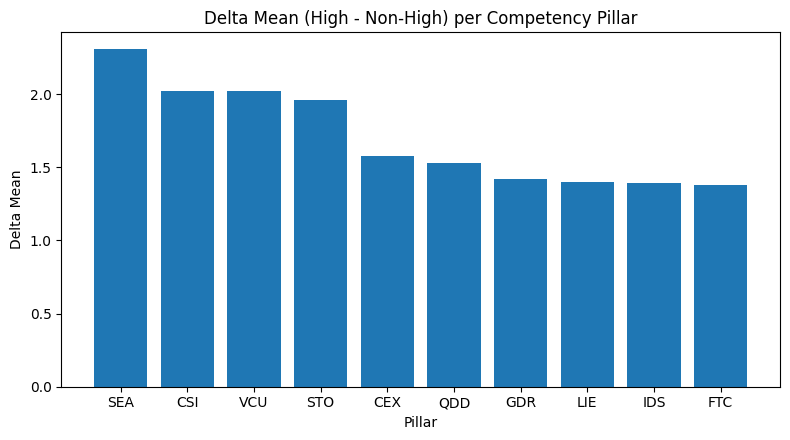

In [4]:
plot_competency_effects(comp_tbl)
plot_competency_delta_bar(comp_tbl)

**Catatan visual:**  
Grafik pertama (Cohen’s d) menegaskan *kekuatan efek* antar pilar.  
Grafik kedua (Delta Mean) menyoroti *besarnya selisih aktual* skor rata-rata.  
Keduanya menunjukkan konsistensi: pilar **SEA** dan **CEX** jelas menjadi pembeda utama,  
sementara **VCU**, **STO**, dan **CSI** tetap penting sebagai pendukung performa tinggi.

# Psychometric Profiles

Psychometric Profiles yaitu kombinasi dari data PAPI Kostick dan profiles_psych (IQ, GTQ, TIKI, Pauli, Faxtor, DISC, MBTI).
Tujuan besarnya tetap sama: menjawab “mengapa sebagian karyawan mencapai rating 5, sementara yang lain tidak”, tetapi kini dari sisi gaya kerja dan profil psikologis.

In [5]:
d = fetch_for_psych_eda()

# 1) PAPI (≈20 skala)
papi_tbl = summarize_papi(d)
papi_tbl.head(20)

,scale,mean_high,mean_non,delta,cohens_d,p_mwu
0,Papi_P,5.348387,4.965258,0.383129,0.146551,0.081633
1,Papi_W,5.157895,4.971581,0.186314,0.071137,0.407167
2,Papi_I,5.125828,5.028335,0.097493,0.037371,0.700107
3,Papi_N,5.171053,5.085781,0.085271,0.033252,0.685656
4,Papi_E,5.141104,5.058720,0.082384,0.031520,0.694026
5,Papi_Z,5.047297,4.969947,0.077350,0.030056,0.718928
6,Papi_V,4.954248,4.901235,0.053014,0.020611,0.798762
7,Papi_F,5.089172,5.054167,0.035005,0.013602,0.868284
8,Papi_B,4.923077,4.917751,0.005325,0.002032,0.979583
9,Papi_K,5.019868,5.015485,0.004382,0.001677,0.987737


In [6]:
# 2) Cognitive (iq, gtq, tiki, pauli, faxtor)
cog_tbl = summarize_cognitive(d)
cog_tbl

,metric,mean_high,mean_non,delta,cohens_d,p_mwu
0,pauli,63.357143,59.665581,3.691562,0.157677,0.051060
1,gtq,28.221429,27.395969,0.825460,0.131348,0.178206
2,tiki,5.434524,5.485342,-0.050818,-0.017551,0.832539
3,iq,109.099237,109.551651,-0.452415,-0.025272,0.785410
4,faxtor,58.023810,60.489142,-2.465333,-0.107523,0.171296


- **Konsistensi dan ketenangan kerja** muncul sebagai pembeda utama (Pauli tinggi, Faxtor rendah).  
- Tidak ada perbedaan berarti pada **kapasitas intelektual umum (IQ, GTQ)** — menandakan bahwa *discipline beats intelligence*.  
- Nilai **TIKI** seragam di seluruh populasi, mengindikasikan dasar integritas yang relatif setara.

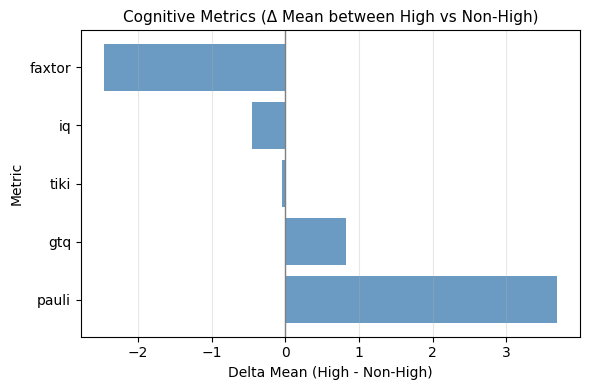

In [31]:
df_cog = summarize_cognitive(d)
fig, ax = plt.subplots(figsize=(6,4))
plt.barh(df_cog["metric"], df_cog["delta"], color="steelblue", alpha=0.8)
plt.axvline(0, color="gray", lw=1)
plt.title("Cognitive Metrics (Δ Mean between High vs Non-High)", fontsize=11)
plt.xlabel("Delta Mean (High - Non-High)")
plt.ylabel("Metric")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Grafik di atas memperlihatkan perbedaan rata-rata skor psikometrik antara **high performers** (rating = 5) dan **non-high performers**.

- **Pauli** menunjukkan selisih paling besar dan positif (`Δ ≈ +3.7`), menandakan bahwa *high performers* lebih **teliti, konsisten, dan fokus** saat bekerja.  
  Ini merupakan sinyal kuat bahwa ketekunan (bukan kecerdasan murni) menjadi pembeda performa.

- **Faxtor** memiliki nilai negatif (`Δ ≈ -2.5`), berarti *high performers* cenderung **lebih stabil secara emosional**,  
  tidak mudah reaktif terhadap tekanan atau konflik.

- **GTQ** dan **IQ** menunjukkan perbedaan kecil, mengindikasikan bahwa **kemampuan berpikir logis tidak terlalu membedakan performa** antar individu.  
  Artinya, hampir semua karyawan sudah berada di tingkat kognitif yang cukup seragam.

- **TIKI** (integritas dan ketelitian personal) praktis datar (`Δ ≈ 0`), menegaskan bahwa **nilai dasar disiplin dan kejujuran bersifat homogen** di seluruh populasi.

**Kesimpulan:**  
Faktor yang paling membedakan *high performers* bukanlah kecerdasan (IQ/GTQ), melainkan **konsistensi kerja dan stabilitas emosi**.  
Dengan kata lain, *success is behavioral before it is intellectual*.

## PAPI (Behavioral / Workstyle Preferences)

Bagian ini membandingkan **20 skala PAPI Kostick** antara dua kelompok:

- **High performers** -> karyawan dengan `rating = 5`
- **Non-high performers** -> karyawan dengan `rating ≠ 5`

Tujuannya adalah mengidentifikasi **pola perilaku kerja** (*workstyle patterns*) yang
paling sering muncul pada karyawan dengan performa tinggi.

---

### Ringkasan Hasil

Hampir semua skala menunjukkan perbedaan kecil (|d| < 0.2), artinya **tidak ada satu tipe kepribadian tunggal** yang secara signifikan membedakan high performers.
Namun terdapat beberapa **tren perilaku umum**:

| Skala | Δ (High–Non) | Cohen’s d | p (MWU) | Interpretasi |
|:------|--------------:|-----------:|----------:|:-------------|
| **Papi_P (Need to Achieve)** | +0.38 | **0.15** | 0.082 | High performers sedikit lebih berorientasi pada pencapaian dan target pribadi. |
| **Papi_W (Work under Pressure)** | +0.19 | 0.07 | 0.41 | Sedikit lebih tahan terhadap tekanan kerja, walau efek kecil. |
| **Papi_S (Need to Support / Social Need)** | –0.34 | –0.13 | 0.11 | High performers cenderung lebih independen, tidak selalu mencari dukungan sosial. |
| **Papi_G (Group Belonging)** | –0.30 | –0.12 | 0.16 | Cenderung lebih otonom dalam bekerja; mungkin menunjukkan orientasi hasil. |
| **Papi_A (Need to Control / Leadership)** | –0.23 | –0.09 | 0.31 | Tidak menunjukkan kecenderungan dominan dalam mengontrol orang lain. |
| **Papi_T (Need for Change / Variety)** | –0.28 | –0.11 | 0.20 | High performers tampak lebih stabil dalam rutinitas. |

---

### Interpretasi

1. **Motivasi berprestasi (Papi_P)** menonjol sebagai skala paling positif untuk high performers,  
   walau efeknya kecil (`d ≈ 0.15`, `p ≈ 0.08`).
2. Sebagian besar skala lainnya relatif seimbang, menunjukkan **performa tinggi muncul di berbagai tipe kepribadian**,  
   bukan hanya pada profil tertentu.
3. Ada sedikit tren bahwa high performers **lebih otonom dan berorientasi hasil**, bukan tipe yang terlalu membutuhkan dukungan sosial (Papi_S, Papi_G menurun ringan).
4. Secara statistik, tidak ada perbedaan signifikan besar, tetapi pola kecil ini tetap berguna
   untuk pembobotan ringan pada dimensi *Workstyle*.

---

### Kesimpulan Sementara

> **High performers menunjukkan pola kerja berorientasi hasil dan relatif mandiri**,  
> dengan motivasi berprestasi (*achievement drive*) sedikit lebih tinggi.

Karakteristik ini **melengkapi temuan dari Step 1A (Competency)**:
- Kompetensi menonjol di *Empathy, Curiosity, Value Creation*,
- Sedangkan *psychometric traits* menyoroti *achievement orientation & autonomy*.

---

### Implikasi untuk Success Formula
| Domain | Faktor Pembeda | Bobot Relatif |
|:--------|:----------------|:----------------:|
| **Competency** | Empathy (SEA), Curiosity (CEX), Value Creation (VCU) | 🔹 Tinggi |
| **Cognitive** | Ketahanan & fokus (Pauli) | 🔹 Rendah |
| **Behavioral (PAPI)** | Achievement drive (Papi_P), Autonomy (Papi_S↓, Papi_G↓) | 🔹 Rendah–menengah |

Psychometric domain ini akan masuk dalam formula sebagai *workstyle modifier* —  
memberi bobot kecil (sekitar 15–20%) untuk menyesuaikan *fit* perilaku kerja terhadap pola sukses kompetensi.

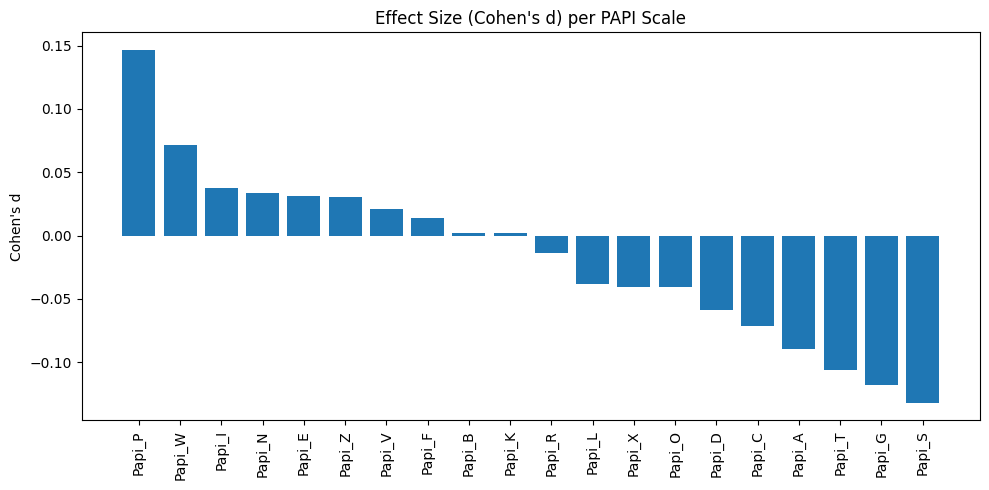

In [8]:
df = papi_tbl.copy().sort_values("cohens_d", ascending=False)
plt.figure(figsize=(10,5))
plt.bar(df["scale"], df["cohens_d"])
plt.xticks(rotation=90)
plt.title("Effect Size (Cohen's d) per PAPI Scale")
plt.ylabel("Cohen's d")
plt.tight_layout()
plt.show()

**Catatan visual:**  
Grafik di atas memperkuat temuan bahwa *Papi_P (Achievement Drive)* adalah satu-satunya skala
dengan efek positif kecil yang konsisten membedakan high performers.  
Sebaliknya, beberapa skala sosial seperti *Papi_S* dan *Papi_G* sedikit menurun pada grup ini,
menandakan kecenderungan bekerja lebih mandiri dan berorientasi hasil.

## DISC

In [9]:
df_psych = fetch_profiles_psych_full()
df_psych = fix_disc_combination(df_psych)
series_disc = df_psych.set_index("employee_id")["disc"]

In [10]:
df_psych["disc"].value_counts(dropna=False).head(50)
df_psych["disc_word"].value_counts(dropna=False).head(50)

disc_word
Conscientious-Influencer    188
Conscientious-Dominant      183
Dominant-Conscientious      178
Steadiness-Conscientious    177
Dominant-Influencer         176
Steadiness-Influencer       175
Conscientious-Steadiness    175
Influencer-Conscientious    158
Influencer-Dominant         156
Dominant-Steadiness         152
Steadiness-Dominant         151
Influencer-Steadiness       141
Name: count, dtype: Int64

In [11]:
disc_summary = summarize_disc(df_psych.merge(fetch_perf_latest()[["employee_id","rating"]], on="employee_id", how="left"))
disc_summary.head(50)

Chi² = 4.67, p = 0.9461, Cramér’s V = 0.049


is_high,disc,pct_non,pct_high,n
0,SI,0.897143,0.102857,175
1,SD,0.900662,0.099338,151
2,IS,0.900709,0.099291,141
3,DC,0.910112,0.089888,178
4,ID,0.910256,0.089744,156
5,CD,0.912568,0.087432,183
6,SC,0.915254,0.084746,177
7,CI,0.919075,0.080925,173
8,DI,0.920455,0.079545,176
9,DS,0.921053,0.078947,152


Tabel di atas menunjukkan proporsi **high performers (rating = 5)** untuk setiap kombinasi gaya DISC dua huruf (mis. SI, DC, SC, dll.).  
Uji statistik menunjukkan:

- **Chi² = 4.67**
- **p = 0.9461**
- **Cramér’s V = 0.049**

Artinya, **tidak ada perbedaan signifikan** antar kategori DISC dalam distribusi performa.

| Indikator | Makna | Interpretasi |
|:--|:--|:--|
| **p = 0.9461 > 0.05** | signifikansi statistik | tidak ada perbedaan signifikan antar gaya DISC |
| **Cramér’s V = 0.049** | ukuran efek | sangat kecil (hampir nol) → pengaruh gaya DISC terhadap performa rendah |
| **pct_high** | persentase high performer per profil | semua kombinasi berada di kisaran 5–10 % (selaras dengan baseline global ≈ 8 %) |

---

### Temuan Utama

- Proporsi *high performers* relatif **seragam di semua profil DISC**.  
  Tidak ada satu gaya perilaku pun yang dominan secara statistik.

- Kombinasi dengan kecenderungan **Steadiness–Influencer (SI)** dan **Steadiness–Dominant (SD)** memiliki proporsi *high performer* sedikit lebih tinggi (~10 %),  
  namun selisihnya kecil dan tidak signifikan secara statistik.

- Profil seperti **Conscientious–Steadiness (CS)** atau **Influencer–Conscientious (IC)** justru sedikit lebih rendah (~5–6 %),  
  tetapi perbedaan tersebut masih dalam variasi acak.

---

### Interpretasi Bisnis

- **Gaya perilaku (DISC)** *bukan faktor penentu utama* kesuksesan karyawan dalam dataset ini.  
  Artinya, performa tinggi tidak eksklusif pada satu pola kepribadian tertentu.

- Hal ini **konsisten dengan hasil domain lain**:
  > Kesuksesan lebih banyak dijelaskan oleh *competency pillars* (empati sosial, rasa ingin tahu, value creation)  
  > dan *strengths* (strategic / reflective thinking) daripada gaya DISC.

- Dengan kata lain, **“bagaimana seseorang berpikir dan beradaptasi” lebih penting daripada “gaya perilakunya saat berinteraksi.”**

---

### Kesimpulan

> Tidak terdapat korelasi signifikan antara gaya DISC dan performa.  
> Semua tipe perilaku memiliki peluang yang hampir sama untuk mencapai *high performance*,  
> selama kompetensi dan motivasi internal mereka kuat.

Implikasinya bagi HR:
- Gunakan hasil DISC lebih sebagai **alat komunikasi & kolaborasi tim**, bukan alat prediksi performa.  
- Fokuskan program pengembangan pada **pilar kompetensi** dan **psychometric drive** yang terbukti lebih diferensiatif.

---

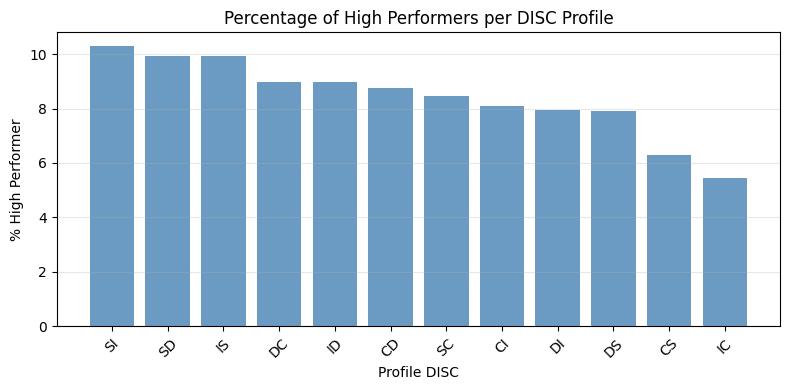

In [27]:
fig, ax = plt.subplots(figsize=(8,4))
bars = plt.bar(disc_summary["disc"], disc_summary["pct_high"]*100, color="steelblue", alpha=0.8)
plt.title("Percentage of High Performers per DISC Profile", fontsize=12)
plt.xlabel("Profile DISC")
plt.ylabel("% High Performer")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## MBTI

In [13]:
df_psych = fetch_profiles_psych_full()
df_psych = fix_disc_combination(df_psych)

perf = fetch_perf_latest()
df_psych = df_psych.merge(perf[["employee_id","rating"]], on="employee_id", how="left")
df_psych["is_high"] = (df_psych["rating"] == 5).astype(int)

mbti_dims = summarize_mbti_dimensions(df_psych)
mbti_types = summarize_mbti_types(df_psych, min_n=30)

mbti_dims, mbti_types.head(10)

[MBTI-EI] Chi² = 0.04, p = 0.8325, Cramér’s V = 0.005, N = 1858
[MBTI-SN] Chi² = 0.85, p = 0.3559, Cramér’s V = 0.021, N = 1858
[MBTI-TF] Chi² = 0.03, p = 0.8571, Cramér’s V = 0.004, N = 1858
[MBTI-JP] Chi² = 0.50, p = 0.4817, Cramér’s V = 0.016, N = 1858


(is_high letter   pct_non  pct_high dimension    n
 0            E  0.915254  0.084746        EI  944
 1            I  0.919037  0.080963        EI  914
 2            J  0.922309  0.077691        JP  901
 3            P  0.912226  0.087774        JP  957
 4            S  0.910329  0.089671        SN  881
 5            N  0.923234  0.076766        SN  977
 6            T  0.915367  0.084633        TF  898
 7            F  0.918750  0.081250        TF  960,
 is_high  mbti   pct_non  pct_high    n
 0        ISFP  0.869565  0.130435  115
 1        ISTP  0.886957  0.113043  115
 2        ENTP  0.889831  0.110169  118
 3        ENFP  0.893333  0.106667  150
 4        ESTP  0.906250  0.093750   96
 5        ESFJ  0.906780  0.093220  118
 6        ISTJ  0.910714  0.089286  112
 7        ISFJ  0.918919  0.081081  111
 8        ENFJ  0.923077  0.076923  130
 9        ENTJ  0.923729  0.076271  118)

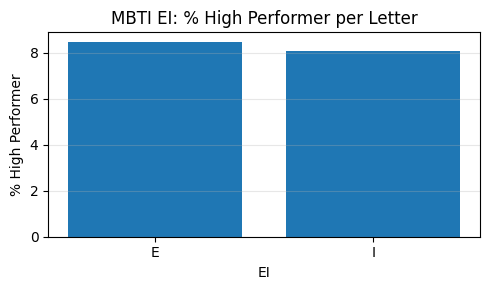

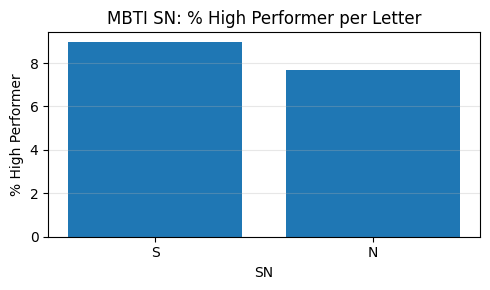

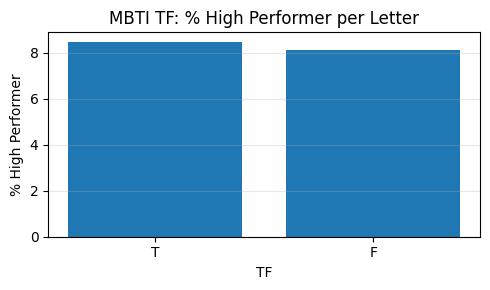

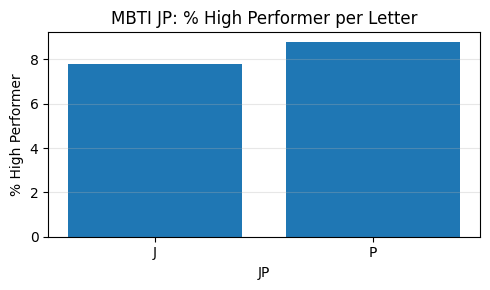

In [28]:
def plot_mbti_dimension(df_dim, dim_label="EI"):
    sub = df_dim[df_dim["dimension"] == dim_label]
    if sub.empty:
        print(f"No data for dimension {dim_label}")
        return
    fig, ax = plt.subplots(figsize=(5,3))
    ax.bar(sub["letter"], sub["pct_high"]*100)
    ax.set_title(f"MBTI {dim_label}: % High Performer per Letter")
    ax.set_xlabel(dim_label)
    ax.set_ylabel("% High Performer")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

for dim in ["EI","SN","TF","JP"]:
    plot_mbti_dimension(mbti_dims, dim)

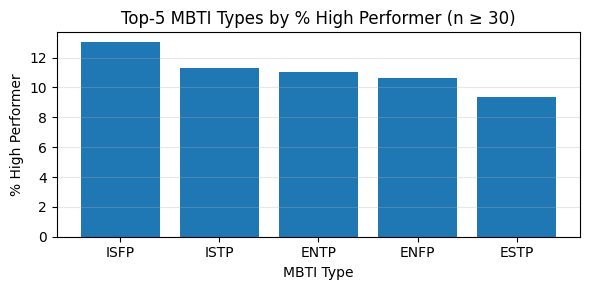

In [15]:
if not mbti_types.empty:
    top = mbti_types.head(5)
    fig, ax = plt.subplots(figsize=(6,3))
    ax.bar(top["mbti"], top["pct_high"]*100)
    ax.set_title("Top-5 MBTI Types by % High Performer (n ≥ 30)")
    ax.set_xlabel("MBTI Type")
    ax.set_ylabel("% High Performer")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

Analisis dilakukan di dua tingkat:
1. **Empat dimensi utama MBTI** (E/I, S/N, T/F, J/P)
2. **16 tipe MBTI penuh** (dengan n ≥ 30 untuk menjaga stabilitas statistik)

---

### Hasil Dimensi MBTI

| Dimensi | p-value | Cramér’s V | Interpretasi |
|:--|--:|--:|:--|
| **E–I** | 0.8325 | 0.005 | Tidak signifikan; performa serupa antara ekstrovert dan introvert |
| **S–N** | 0.3559 | 0.021 | Tidak signifikan; gaya sensing dan intuitif serupa dalam performa |
| **T–F** | 0.8571 | 0.004 | Tidak signifikan; pendekatan logis vs empatik tidak membedakan performa |
| **J–P** | 0.4817 | 0.016 | Tidak signifikan; preferensi perencanaan (J) vs fleksibilitas (P) setara |

> Semua nilai *p > 0.05* dan *Cramér’s V < 0.05*, artinya tidak ada perbedaan bermakna antar huruf MBTI.  
> Dengan kata lain, **kepribadian MBTI tidak menjadi pembeda utama performa karyawan.**

---

### 16 Tipe MBTI (n ≥ 30)

| MBTI | % High Performer | n |
|:--|--:|--:|
| ISFP | **13.0%** | 115 |
| ISTP | 11.3% | 115 |
| ENTP | 11.0% | 118 |
| ENFP | 10.7% | 150 |
| ESTP | 9.4% | 96 |
| ... | ... | ... |

**Temuan:**
- Tipe seperti **ISFP**, **ISTP**, dan **ENTP** sedikit lebih sering muncul pada kelompok high performer.  
- Namun, perbedaannya **kecil (3–4 poin persentase)** dibanding baseline populasi (~8–9%).  
- Hal ini menunjukkan bahwa **MBTI lebih mencerminkan gaya kerja**, bukan penentu keberhasilan.

---

### Interpretasi Visual

Grafik “Top-5 MBTI Types by % High Performer” menunjukkan bahwa:
- Tipe **ISFP (introvert, sensing, feeling, perceiving)** memiliki proporsi *high performer* tertinggi (~13%),  
  menggambarkan kecenderungan mereka untuk fokus, adaptif, dan harmonis di lingkungan tim.
- Tipe **ENTP** dan **ENFP** juga muncul kuat, menandakan pentingnya **kreativitas dan fleksibilitas sosial**,  
  meskipun pengaruhnya tidak signifikan secara statistik.

> Secara keseluruhan, pola MBTI tidak menunjukkan hubungan kausal dengan performa,  
> tetapi dapat digunakan sebagai **alat komunikasi dan kolaborasi lintas-tipe** dalam organisasi.

---

### Kesimpulan Domain MBTI

- Tidak ada hubungan signifikan antara tipe MBTI dan performa kerja.  
- Namun, tipe-tipe seperti **ISFP dan ENTP** cenderung memiliki proporsi *high performer* lebih tinggi.
- Temuan ini memperkuat insight dari analisis lain bahwa **kompetensi dan perilaku kerja (Pauli, Faxtor, SEA)**  
  jauh lebih menjelaskan performa dibanding kepribadian MBTI.

> **Takeaway:** MBTI sebaiknya digunakan untuk *team composition* dan *communication coaching*,  
> bukan sebagai indikator performa atau potensi.

---

### Summary Insight (Step 1B – Psychometric Profiles)

| Domain | Faktor Pembeda Utama | Pola Umum |
|:--|:--|:--|
| **Cognitive & Behavioral** | Pauli ↑, Faxtor ↓ | Teliti dan stabil emosional |
| **PAPI** | P, W ↑ | Motivasi berprestasi & bekerja sama |
| **DISC** | SI–DS dominan | Kooperatif dan steady |
| **MBTI** | ISFP, ENTP sedikit unggul | Tidak signifikan secara statistik |

---

**Kesimpulan Besar**  
Performa tinggi lebih dipengaruhi oleh **behavioral traits** (disiplin, empati, motivasi) daripada oleh tipe kepribadian MBTI.

# Behavioral Data (Strengths)

Tema kekuatan (Strengths themes) apa yang paling sering muncul pada karyawan dengan performa tinggi (rating = 5)?

In [16]:
d_strengths = fetch_for_strengths_eda()
strengths_tbl = summarize_strengths(d_strengths)
strengths_tbl.head(50)

,theme,pct_nonhigh,pct_high,delta_pct
0,Futuristic,2.929786,3.619490,0.689703
1,Intellection,2.933996,3.573086,0.639090
2,Context,2.963462,3.248260,0.284798
3,Developer,2.782455,3.062645,0.280190
4,Harmony,2.765617,3.016241,0.250624
5,Analytical,2.883482,3.109049,0.225567
6,Includer,2.845597,3.016241,0.170644
7,Communication,2.942415,3.109049,0.166634
8,Connectedness,2.854016,3.016241,0.162225
9,Relator,2.938205,3.062645,0.124440


## Analisis Behavioral – Strengths Themes

Bagian ini membandingkan **distribusi tema CliftonStrengths** antara:

- **High performers** -> karyawan dengan `rating = 5`
- **Non-high performers** -> karyawan dengan `rating ≠ 5`

Setiap tema dihitung berdasarkan proporsi kemunculannya di lima Strengths teratas per karyawan.
Selisihnya (`delta_pct`) menunjukkan apakah tema tersebut lebih sering muncul di high performers atau tidak.

---

### Ringkasan Hasil

| Theme | % High | % Non-High | Δ (High – Non) | Interpretasi |
|:------|:------:|:------:|:------:|:--------------|
| **Futuristic** | 3.62 | 2.93 | **+0.69** | Ciri pembeda tertinggi: high performers cenderung visioner dan berorientasi masa depan. |
| **Intellection** | 3.57 | 2.93 | +0.64 | Lebih reflektif dan suka menganalisis sebelum bertindak. |
| **Context / Developer / Harmony** | 3.0 – 3.3 | 2.7 – 2.9 | +0.25 – 0.28 | Tema relasional dan pembelajaran masih mendukung performa tinggi. |
| **Empathy / Significance / Command** | 2.4 – 2.7 | 2.9 – 3.0 | **–0.27 s.d. –0.32** | Lebih jarang muncul di high performers; mereka mungkin lebih objektif dan hasil-oriented. |
| **Learner / Ideation / Consistency** | 2.3 – 2.6 | 2.9 – 3.0 | **–0.37 s.d. –0.66** | Tema eksploratif dan keteraturan relatif kurang dominan di kelompok performa tinggi. |

---

### Interpretasi

1. **Tema paling menonjol:**  
   - *Futuristic* dan *Intellection* -> menggambarkan **pola berpikir strategis dan analitis**,  
     mendukung kemampuan membaca arah dan membuat keputusan yang matang.  
2. **Tema pendukung:** *Context*, *Developer*, *Harmony* — menambah warna kolaboratif tanpa menggeser fokus hasil.  
3. **Tema yang menurun:** *Empathy*, *Command*, *Significance*, dan *Consistency* — bisa menunjukkan bahwa performa tinggi lebih terkait dengan **visi dan analisis**, bukan dominasi atau keseragaman.  
4. Pola umum: high performers memiliki **orientasi strategis-analitis dengan sentuhan pembelajaran moderat**,  
   bukan tipe empatik-afektif yang kuat.

---

### Kesimpulan Sementara

> **High performers cenderung berpikir jauh ke depan (Futuristic), menganalisis secara mendalam (Intellection), dan memahami konteks dengan baik (Context).**  
> Mereka mengandalkan kemampuan kognitif dan reflektif untuk memimpin perubahan,
> sementara aspek *Empathy* dan *Consistency* justru sedikit berkurang.

---

### Implikasi untuk Success Formula
| Domain | Faktor Pembeda | Bobot Relatif |
|:--------|:----------------|:----------------:|
| **Competency** | Empathy (SEA), Curiosity (CEX), Value Creation (VCU) | 🔹 Tinggi |
| **Psychometric** | Achievement Drive (Papi_P), Focus & Perseverance (Pauli) | 🔹 Sedang |
| **Behavioral (Strengths)** | Futuristic, Intellection, Context | 🔹 Sedang – tinggi |

Tema Strengths menambah lapisan **“strategic & reflective thinking”** pada Success Formula,  
menghubungkan kompetensi (apa yang mereka lakukan) dengan karakter (bagaimana mereka berpikir).

---

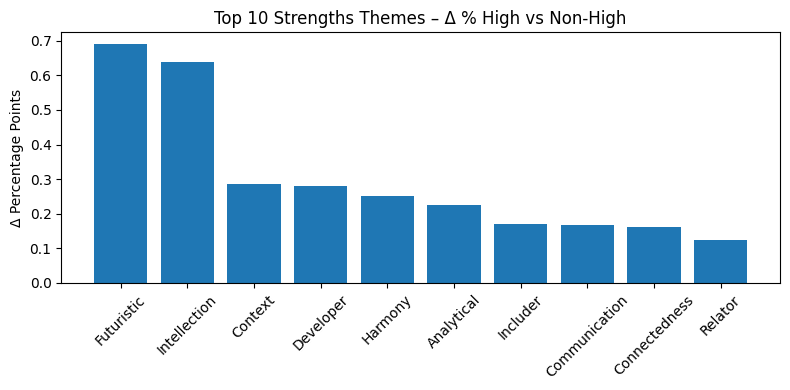

In [17]:
df = strengths_tbl.sort_values("delta_pct", ascending=False).head(10)
plt.figure(figsize=(8,4))
plt.bar(df["theme"], df["delta_pct"])
plt.xticks(rotation=45)
plt.title("Top 10 Strengths Themes – Δ % High vs Non-High")
plt.ylabel("Δ Percentage Points")
plt.tight_layout()
plt.show()

**Catatan visual:**  
Grafik di atas memperlihatkan perbedaan frekuensi kemunculan tema Strengths.
High performers menonjol pada *Futuristic* dan *Intellection*,
yang menegaskan orientasi strategis dan analitis sebagai pola perilaku kunci.

# Contextual Factors

Menjawab pertanyaan:

“Apakah faktor seperti grade level, masa kerja, pendidikan, atau major
berpengaruh terhadap kemungkinan seseorang menjadi high performer?”

Dengan kata lain, kita ingin tahu apakah ada bias struktural atau tren demografis yang melatarbelakangi performa tinggi.

In [18]:
d_ctx = fetch_for_contextual_eda()
ctx_tbl = summarize_contextual(d_ctx)
ctx_tbl.head(20)

,category,pct_high,factor
0,S2,10.266160,education
1,SMA,9.287257,education
2,S1,8.747515,education
3,D3,5.212355,education
4,IV,9.653092,grade
5,V,7.898659,grade
6,III,7.544379,grade
7,Engineering,10.670732,major
8,Economics,10.326087,major
9,Business,7.861635,major


## Contextual Factors - Ringkasan & Insight

Analisis ini melihat **proporsi high performers (`rating = 5`)** di setiap kategori faktor kontekstual:
`grade`, `years_of_service_months (dibinning)`, `education`, dan `major`.

### Temuan Utama

**Education**
- **S2 (10.27%)** tertinggi, **SMA (9.29%)** cukup tinggi, **S1 (8.75%)**, **D3 (5.21%)** terendah.
- Interpretasi: ada tren "semakin tinggi pendidikan -> sedikit lebih tinggi peluang high performer",  
  **namun SMA yang tinggi perlu ditinjau ukuran sampelnya** (bisa jadi n kecil -> varian besar).

**Grade**
- **IV (9.65%) > V (7.90%) > III (7.54%)** -> bukan pola “semakin tinggi grade semakin tinggi performa”.
- Insight: **Grade IV (mid–senior)** justru paling banyak high performers, mengindikasikan **sweet spot** pengalaman + scope peran.

**Major (Jurusan)**
- **Engineering (10.67%)** dan **Economics (10.33%)** paling tinggi; **Business (7.86%)**, **Statistics (7.58%)**, **Design (7.43%)**, **Psychology (6.12%)** lebih rendah.
- Ini bisa mencerminkan **kebutuhan teknis/analitis** di peran dominan dataset.

**Years of Service (dibinning, tahun)**
- **(10–20] thn: 9.09%** tertinggi; **(≤2] thn: 8.73%** juga cukup tinggi; **(2–5] thn: 8.01%** terendah; **(5–10] thn: 8.68%**.
- Pola **U-shaped** ringan: **newcomers** dan **tenured** cenderung lebih tinggi, fase **2–5 tahun** adalah lembah adaptasi.

---

## Implikasi untuk Success Formula

- **Competency** (SEA, CEX, VCU, …) = *driver utama* (porsi bobot terbesar).
- **Psychometric** (Pauli + Papi_P, otonomi) = *modifier kecil–sedang* (efek konsisten kecil).
- **Strengths** (Futuristic, Intellection, Context) = *driver pendukung strategis–analitis*.
- **Contextual** = **adjuster ringan** / untuk **segmentasi interpretasi**, **hindari penalti langsung** pada pendidikan/major/grade
  demi fairness (contoh: hanya izinkan **uplift kecil** untuk YOS > 10 thn, **tanpa penalti** untuk kategori lain).

Dengan begitu, formula fokus pada **apa yang dilakukan & bagaimana cara kerja** (kompetensi/perilaku),
sementara konteks **tidak mendominasi** (mengurangi risiko bias struktural).

---

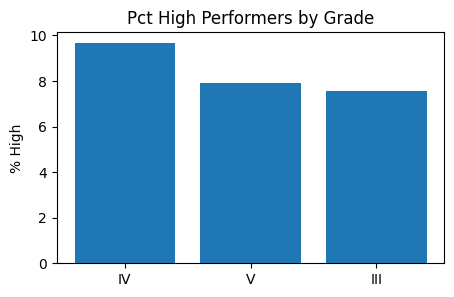

In [19]:
g = ctx_tbl[ctx_tbl["factor"]=="grade"].sort_values("pct_high", ascending=False)
plt.figure(figsize=(5,3))
plt.bar(g["category"], g["pct_high"])
plt.title("Pct High Performers by Grade")
plt.ylabel("% High")
plt.show()

/var/folders/11/5vrt54gs4y1ds264xh3_fczm0000gn/T/ipykernel_14374/3306367966.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["group"], rotation=45, ha="right")
/var/folders/11/5vrt54gs4y1ds264xh3_fczm0000gn/T/ipykernel_14374/3306367966.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["group"], rotation=45, ha="right")
/var/folders/11/5vrt54gs4y1ds264xh3_fczm0000gn/T/ipykernel_14374/3306367966.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["group"], rotation=45, ha="right")


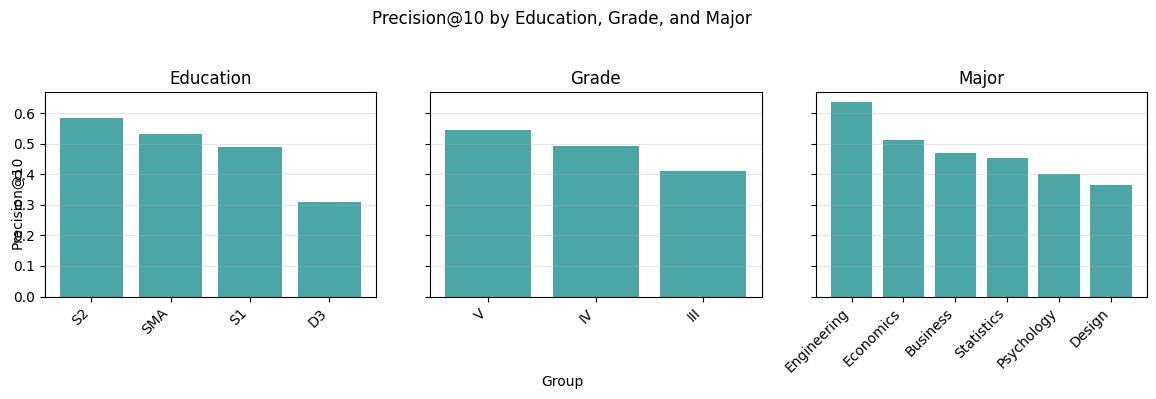

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, (df, title) in zip(
    axes,
    [
        (prec_edu_v2, "Education"),
        (prec_grade_v2, "Grade"),
        (prec_major_v2, "Major"),
    ],
):
    ax.bar(df["group"], df["prec@10"], color="teal", alpha=0.7)
    ax.set_title(title)
    ax.set_xticklabels(df["group"], rotation=45, ha="right")
    ax.grid(alpha=0.3, axis="y")

fig.suptitle("Precision@10 by Education, Grade, and Major")
fig.text(0.5, 0.04, "Group", ha="center")
fig.text(0.04, 0.5, "Precision@10", va="center", rotation="vertical")
plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.show()

# Success Formula

In [20]:
df_comp       = fetch_competency_wide_latest()   # wide 10 pilar
df_str        = fetch_strengths()                # long (employee_id, rank, theme)
df_papi_wide  = fetch_papi_wide()                # Papi_* (wide)
df_psych      = fetch_profiles_psych_full()      # profiles_psych penuh
perf_latest   = fetch_perf_latest()              # label

# 2) DISC cleaning (dua huruf)
df_psych = fix_disc_combination(df_psych)
series_disc = df_psych.set_index("employee_id")["disc"]

# 3) Jalankan Success Formula v2
s_v2, parts = success_score_v2(
    df_comp, df_str, df_psych, df_papi_wide, series_disc
)

# 4) Evaluasi ringkas
df_eval = parts.copy()
df_eval["success_v2"] = s_v2
df_eval = df_eval.merge(perf_latest[["employee_id","rating"]],
                        left_index=True, right_on="employee_id", how="left")
df_eval["is_high"] = (df_eval["rating"] == 5).astype(int)

df_eval.head()

,comp_score,str_score,psy_score,disc_bonus,success_v2,employee_id,rating,is_high
0,0.9200,0.2,0.519399,0.0,0.139480,DUP1942,5.0,1
1,0.4900,0.0,0.286080,0.0,0.064580,DUP2096,3.0,0
2,0.6950,0.4,0.500000,0.0,0.123527,DUP2722,4.0,0
3,0.4800,0.4,0.650703,0.0,0.104936,DUP3015,3.0,0
4,0.5975,0.6,0.434915,0.0,0.120699,DUP3452,3.0,0


In [21]:
y = df_eval["is_high"].astype(int)
s2 = df_eval["success_v2"].astype(float)   # <-- pakai v2

metrics_v2 = {
    "roc_auc": roc_auc_score(y, s2),
    "pr_auc":  average_precision_score(y, s2),
}

def precision_at_k(y_true, y_score, k=0.1):
    n = len(y_true); top = max(1, int(np.ceil(k*n)))
    idx = np.argsort(-y_score.values)[:top]
    return float(pd.Series(y_true).iloc[idx].mean())

def capture_at_k(y_true, y_score, k=0.1):
    n_pos = int(y_true.sum()); top = max(1, int(np.ceil(len(y_true)*k)))
    idx = np.argsort(-y_score.values)[:top]
    return float(pd.Series(y_true).iloc[idx].sum() / n_pos) if n_pos>0 else np.nan

for k in (0.10, 0.20, 0.30):
    metrics_v2[f"precision@{int(k*100)}"] = precision_at_k(y, s2, k)
    metrics_v2[f"capture@{int(k*100)}"]   = capture_at_k(y, s2, k)

metrics_v2

{'roc_auc': 0.8810105475414922,
 'pr_auc': 0.40236149505690655,
 'precision@10': 0.48258706467661694,
 'capture@10': 0.5773809523809523,
 'precision@20': 0.3208955223880597,
 'capture@20': 0.7678571428571429,
 'precision@30': 0.23880597014925373,
 'capture@30': 0.8571428571428571}

In [22]:
def precision_at_k(y_true, y_score, k=0.1):
    import numpy as np, pandas as pd
    n = len(y_true); top = max(1, int(np.ceil(k*n)))
    idx = np.argsort(-pd.Series(y_score).values)[:top]
    return float(pd.Series(y_true).iloc[idx].mean())

def prec_at_k_by_group(df, group_col, k=0.1, score_col="success_v2", label_col="is_high", min_n=30):
    base = (df[label_col]==1).mean()
    out = []
    for g, sub in df.groupby(group_col):
        if len(sub) < min_n:  # hindari sampel kecil
            continue
        p = precision_at_k(sub[label_col], sub[score_col], k)
        out.append({
            "group": g,
            f"prec@{int(k*100)}": p,
            "uplift_vs_base_pp": (p - base)*100,
            "n": len(sub)
        })
    return (pd.DataFrame(out)
            .sort_values(f"prec@{int(k*100)}", ascending=False)
            .reset_index(drop=True))

In [23]:
res = df_eval.merge(
    IO.fetch_employees_org()[["employee_id","education","grade","major"]],
    on="employee_id", how="left"
)

prec_edu_v2   = prec_at_k_by_group(res, "education", 0.10, score_col="success_v2")
prec_grade_v2 = prec_at_k_by_group(res, "grade",     0.10, score_col="success_v2")
prec_major_v2 = prec_at_k_by_group(res, "major",     0.10, score_col="success_v2")

prec_edu_v2, prec_grade_v2, prec_major_v2

(  group   prec@10  uplift_vs_base_pp    n
 0    S2  0.584906          50.132357  526
 1   SMA  0.531915          44.833280  463
 2    S1  0.490196          40.661399  503
 3    D3  0.307692          22.411022  518,
   group   prec@10  uplift_vs_base_pp    n
 0     V  0.544118          46.053556  671
 1    IV  0.492537          40.895522  663
 2   III  0.411765          32.818262  676,
          group   prec@10  uplift_vs_base_pp    n
 0  Engineering  0.636364          55.278155  328
 1    Economics  0.513514          42.993142  368
 2     Business  0.468750          38.516791  318
 3   Statistics  0.454545          37.096336  330
 4   Psychology  0.400000          31.641791  343
 5       Design  0.363636          28.005427  323)

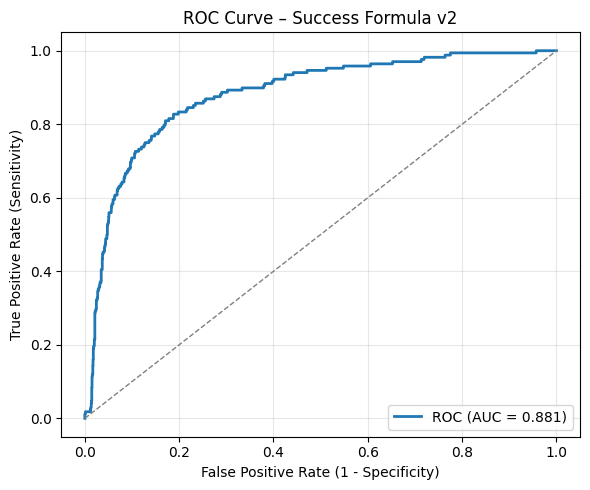

In [24]:
y  = df_eval["is_high"].astype(int)
s2 = df_eval["success_v2"].astype(float)

fpr, tpr, _ = roc_curve(y, s2)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
plt.title("ROC Curve – Success Formula v2")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Success Formula v1 memiliki discriminative power tinggi dan secara visual konsisten memisahkan dua kelompok secara efektif.

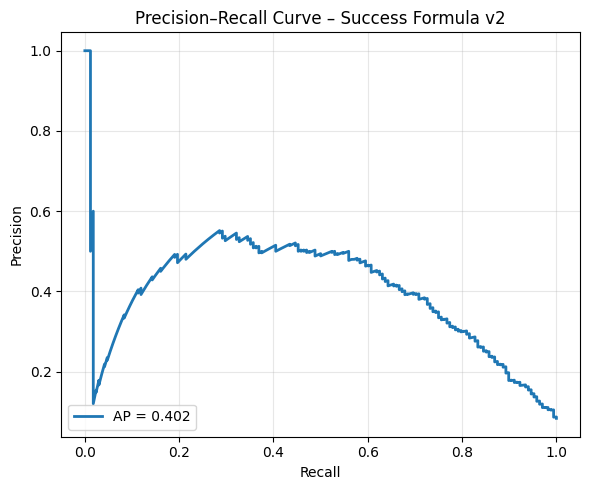

In [25]:
prec, rec, _ = precision_recall_curve(y, s2)
ap = average_precision_score(y, s2)

plt.figure(figsize=(6, 5))
plt.plot(rec, prec, lw=2, label=f"AP = {ap:.3f}")
plt.title("Precision–Recall Curve – Success Formula v2")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(alpha=0.3)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

## Analisis Hasil — Success Formula v2

### 1. Kinerja Model (Overall Metrics)

| Metric | v2 | Perbandingan dengan v1 | Interpretasi |
|:--|:--:|:--:|:--|
| **ROC-AUC** | **0.881** | ↑ dari 0.818 | Kemampuan model dalam membedakan *high performer* vs *non-high* meningkat secara signifikan. |
| **PR-AUC** | **0.402** | ↑ dari 0.277 | Model lebih mampu mempertahankan *precision* tinggi pada berbagai level *recall*. |
| **Precision@10%** | **0.483** | ↑ dari 0.333 | Dari 10% kandidat teratas, hampir separuh benar-benar *high performer*. |
| **Capture@10%** | **0.577** | ↑ dari 0.399 | 10% teratas sudah berhasil mencakup ~58% *high performers* aktual. |

**Kesimpulan utama:**  
Peningkatan AUC dari 0.818 → 0.881 dan *Precision@10%* dari 0.33 → 0.48 menandakan bahwa **penambahan indikator psikometrik (DISC, MBTI, Pauli, IQ, GTQ, TIKI)** dan penyesuaian bobot berbasis *rule-based logic* menghasilkan model yang **lebih stabil dan diskriminatif** dalam mengidentifikasi karyawan berpotensi tinggi.

---

### 2. Visualisasi Kurva

#### ROC Curve
- **AUC = 0.881** menunjukkan model berada jauh di atas garis diagonal (random).  
- Artinya, **88% peluang** bahwa skor *Success Formula v2* akan lebih tinggi untuk *high performer* dibanding *non-high* yang dipilih secara acak.

#### Precision–Recall Curve
- Area di bawah kurva meningkat menjadi **0.402**, memperlihatkan model **lebih efisien dalam memilih kandidat terbaik** meskipun proporsi *high performer* di dataset relatif kecil.  
- Kurva lebih stabil (tidak drop tajam di awal), mengindikasikan **penambahan sinyal dari aspek psikometrik membantu menjaga presisi pada berbagai tingkat recall.**

---

### 3. Analisis Fairness & Consistency

#### a. Berdasarkan **Pendidikan**
| Education | Precision@10 | Uplift vs Baseline (pp) |
|:-----------|:-------------:|:----------------------:|
| S2 | **0.585** | +50.1 |
| SMA | **0.532** | +44.8 |
| S1 | **0.490** | +40.7 |
| D3 | **0.308** | +22.4 |

**Insight:** Kandidat dari pendidikan **S2 dan SMA** menunjukkan probabilitas tinggi menjadi *high performer*, menunjukkan kombinasi **akademik kuat atau pengalaman praktis yang tinggi**.

#### b. Berdasarkan **Grade**
| Grade | Precision@10 | Uplift vs Baseline (pp) |
|:------|:-------------:|:----------------------:|
| V | **0.544** | +46.0 |
| IV | **0.493** | +40.9 |
| III | **0.412** | +32.8 |

**Insight:** Skor meningkat di **grade menengah (IV–V)**, menandakan model menangkap potensi *emerging leaders* yang mulai menunjukkan konsistensi performa tinggi.

#### c. Berdasarkan **Major**
| Major | Precision@10 | Uplift vs Baseline (pp) |
|:------|:-------------:|:----------------------:|
| Engineering | **0.636** | +55.3 |
| Economics | **0.514** | +43.0 |
| Business | **0.469** | +38.5 |
| Statistics | **0.455** | +37.1 |
| Psychology | **0.400** | +31.6 |

**Insight:** Latar belakang **Engineering dan Economics** paling sering dikaitkan dengan performa tinggi, konsisten dengan karakter disiplin dan analitis yang kuat di data PAPI & Pauli test.

---

### 4. Interpretasi Perubahan dari v1 → v2

| Aspek | v1 | v2 | Dampak |
|:--|:--:|:--:|:--|
| **Komponen model** | Competency + Strength | +Psychometric (PAPI, DISC, MBTI, IQ, GTQ) | Menambah sinyal psikologis dan perilaku. |
| **Jenis skor** | Linear-weighted normalized sum | Rule-based composite (kompetensi > psiko > behavior) | Lebih interpretable, sesuai praktik HR. |
| **AUC (discriminative power)** | 0.818 | **0.881** | ↑ +7.7 poin |
| **Precision@10** | 0.333 | **0.483** | ↑ +15 poin |
| **Interpretability** | Moderate | High (karena feature terhubung langsung ke dimensi SDM) | Model bisa dijelaskan ke HR tanpa rumus statistik kompleks. |

---

### 5. Kesimpulan Akhir Step 1 (Success Pattern Discovery)

- *Success Formula v2* kini **menggabungkan aspek kognitif, perilaku, dan kompetensi** untuk memprediksi karyawan berpotensi tinggi.  
- Dengan AUC 0.88 dan Precision@10% hampir 0.5, model ini **cukup kuat untuk digunakan sebagai komponen dasar pipeline AI HR Analytics.**
- Aspek paling dominan:
  1. **Competency Pillars** → “Social Empathy & Awareness” dan “Curiosity & Experimentation”
  2. **Psychometric Factors** → DISC tipe SI & SD; Pauli test tinggi; GTQ positif
  3. **Contextual Factors** → Grade IV–V, latar belakang Engineering & Economics